# Australian Rainfall Prediction with Machine Learning

This project builds a **binary classification model** to predict whether it will rain the following day using Australian weather observations.

Two classification approaches are compared:

- **Random Forest Classifier**
- **Logistic Regression**

The project focuses on an end-to-end machine-learning workflow: data inspection, feature engineering, preprocessing, stratified model validation, hyperparameter tuning, model evaluation, and feature-importance analysis.

> **Portfolio note:** This notebook is adapted from an IBM Skills Network machine-learning final project. The implementation, completed exercises, analysis, model comparison, and interpretation presented here reflect my own project work.

## Dataset

The weather observations originate from the **Australian Government Bureau of Meteorology** and were distributed for this project through IBM Skills Network.

The original dataset contains daily weather observations from multiple locations across Australia.

Key variables include:

| Feature | Description | ML Type |
| --- | --- | --- |
| `Location` | Observation location | Categorical |
| `MinTemp`, `MaxTemp` | Daily minimum and maximum temperature | Numerical |
| `Rainfall` | Daily rainfall amount | Numerical |
| `Evaporation`, `Sunshine` | Evaporation and bright sunshine | Numerical |
| `WindGustDir`, `WindDir9am`, `WindDir3pm` | Wind direction | Categorical |
| `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm` | Wind speed | Numerical |
| `Humidity9am`, `Humidity3pm` | Relative humidity | Numerical |
| `Pressure9am`, `Pressure3pm` | Atmospheric pressure | Numerical |
| `Cloud9am`, `Cloud3pm` | Cloud cover | Numerical |
| `Temp9am`, `Temp3pm` | Temperature at observation time | Numerical |
| `RainToday` | Whether it rained today | Binary categorical |
| `RainTomorrow` | Whether it rains tomorrow | **Target** |

### Forecasting assumption

This notebook predicts `RainTomorrow` using weather observations available from the current day. Therefore, the model should be interpreted as a **next-day rainfall classifier based on current-day observations**.

## 1. Imports

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

## 2. Load and Inspect the Data

The dataset is loaded directly from the course-hosted CSV file. Initial inspection is used to understand the shape, columns, data types, and missing-value pattern before making preprocessing decisions.

In [33]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [34]:
# Missing-value overview
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    })
    .sort_values("missing_pct", ascending=False)
)

display(missing_summary)

,missing_count,missing_pct
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


## 3. Missing-Value Strategy

Several variables contain substantial missing data. For this project, a **complete-case approach** is used by removing rows containing missing values.

This is intentionally simple, but it has an important limitation: dropping incomplete rows can reduce the dataset substantially and may introduce selection bias. A production version should compare this approach with appropriate imputation strategies.

In [35]:
df = df.dropna().copy()

print("Shape after dropping rows with missing values:", df.shape)
df.info()

Shape after dropping rows with missing values: (56420, 23)
<class 'pandas.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  str    
 1   Location       56420 non-null  str    
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  str    
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  str    
 10  WindDir3pm     56420 non-null  str    
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Clo

## 4. Localize the Model to the Melbourne Region

Weather patterns vary substantially across Australia. To reduce geographic heterogeneity, the project focuses on three nearby locations:

- Melbourne
- Melbourne Airport
- Watsonia

`Location` is retained as a categorical feature so the model can still learn local differences within this region.

In [36]:
melbourne_locations = ["Melbourne", "MelbourneAirport", "Watsonia"]

df = df[df["Location"].isin(melbourne_locations)].copy()

print("Localized dataset shape:", df.shape)
print(df["Location"].value_counts())

Localized dataset shape: (7557, 23)
Location
MelbourneAirport    2929
Watsonia            2730
Melbourne           1898
Name: count, dtype: int64


## 5. Feature Engineering: Season

Weather is seasonal, so the calendar date is transformed into an Australian season:

- Summer: December–February
- Autumn: March–May
- Winter: June–August
- Spring: September–November

The raw `Date` column is then removed.

In [37]:
def date_to_season(date):
    month = date.month

    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    return "Spring"


df["Date"] = pd.to_datetime(df["Date"])
df["Season"] = df["Date"].apply(date_to_season)
df = df.drop(columns="Date")

display(df.head())

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Season
64191,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,SW,...,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes,Summer
64192,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,SSE,...,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No,Summer
64193,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,S,...,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No,Summer
64194,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,SSE,...,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No,Summer
64195,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,SSE,...,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No,Summer


## 6. Define Features and Target

In [38]:
X = df.drop(columns="RainTomorrow")
y = df["RainTomorrow"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7557, 22)
Target shape: (7557,)


## 7. Check Class Balance

In [39]:
class_counts = y.value_counts()
class_rates = y.value_counts(normalize=True)

display(pd.DataFrame({
    "count": class_counts,
    "proportion": class_rates
}))

rain_rate = class_rates["Yes"]
baseline_accuracy = class_rates["No"]
estimated_rainy_days_per_year = rain_rate * 365

print(f"Rain rate: {rain_rate:.2%}")
print(f"Estimated rainy days per year: {estimated_rainy_days_per_year:.1f}")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.2%}")

,count,proportion
RainTomorrow,,
No,5766,0.763001
Yes,1791,0.236999


Rain rate: 23.70%
Estimated rainy days per year: 86.5
Majority-class baseline accuracy: 76.30%


### Class-balance interpretation

The localized dataset contains approximately:

- **76% `No`**
- **24% `Yes`**

A classifier that always predicts `No` would already achieve roughly **76% accuracy**. Therefore, accuracy alone is not sufficient for judging model quality.

The train/test split and cross-validation use **stratification** to preserve class proportions. Evaluation also considers precision, recall, F1-score, and the confusion matrix, with particular attention to the positive (`Yes`) class.

## 8. Train/Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (6045, 22)
Test set: (1512, 22)

Training target distribution:
RainTomorrow
No     0.762945
Yes    0.237055
Name: proportion, dtype: float64

Test target distribution:
RainTomorrow
No     0.763228
Yes    0.236772
Name: proportion, dtype: float64


## 9. Preprocessing Pipeline

In [41]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "str", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Categorical features:
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']


In [42]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The preprocessing is kept inside a `Pipeline` so transformations are learned **only from training folds** during cross-validation. This reduces the risk of data leakage between training and validation data.

## 10. Random Forest Classifier

In [43]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevalu

In [44]:
print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print(f"\nBest cross-validation accuracy: {rf_grid_search.best_score_:.3f}")
print(f"Test accuracy: {rf_grid_search.score(X_test, y_test):.3f}")

Best Random Forest parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best cross-validation accuracy: 0.852
Test accuracy: 0.845


### Random Forest Evaluation

In [45]:
rf_pred = rf_grid_search.predict(X_test)

print("Random Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.75      0.51      0.61       358

    accuracy                           0.84      1512
   macro avg       0.81      0.73      0.76      1512
weighted avg       0.84      0.84      0.83      1512



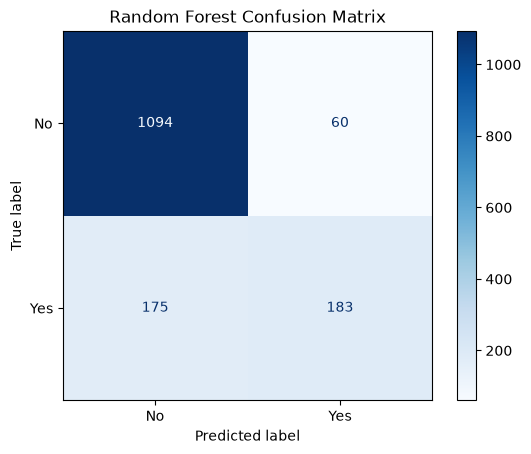

In [46]:
rf_conf_matrix = confusion_matrix(
    y_test,
    rf_pred,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_conf_matrix,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

### Random Forest interpretation

In the completed project run, Random Forest achieved approximately:

- **84% accuracy**
- **75% precision** for `Yes`
- **51% recall / True Positive Rate** for `Yes`
- **60% F1-score** for `Yes`

The overall accuracy is clearly above the majority-class baseline, but the positive-class recall remains limited: the model identifies only about half of the actual rainy days.

## 11. Random Forest Feature Importance

In [47]:
rf_model = rf_grid_search.best_estimator_["classifier"]

encoded_categorical_features = (
    rf_grid_search.best_estimator_["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

feature_names = numeric_features + list(encoded_categorical_features)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(importance_df.head(20))

,Feature,Importance
9,Humidity3pm,0.120752
11,Pressure3pm,0.090827
10,Pressure9am,0.085730
4,Sunshine,0.081560
5,WindGustSpeed,0.050779
15,Temp3pm,0.045733
1,MaxTemp,0.041407
0,MinTemp,0.040418
14,Temp9am,0.039146
8,Humidity9am,0.036119


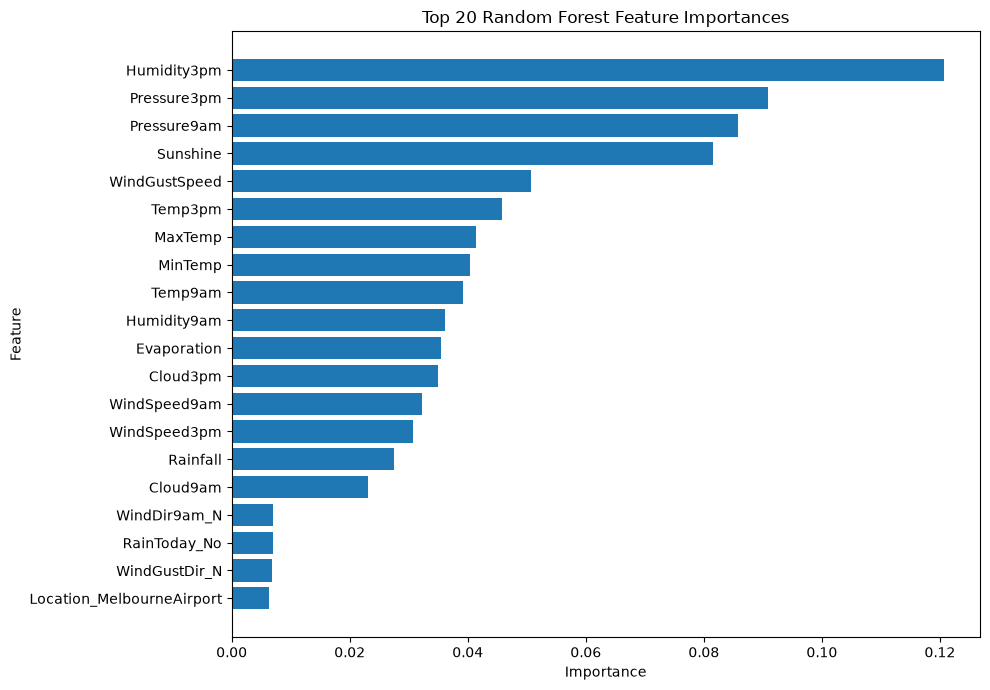

In [48]:
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In the completed run, **`Humidity3pm`** was the most important individual feature.

Random Forest impurity-based feature importance measures how strongly the fitted model relies on each transformed feature. It does **not** show the direction of the relationship, and one-hot encoding distributes the importance of a categorical variable across multiple dummy variables.

## 12. Logistic Regression

Logistic Regression provides a simpler linear baseline for comparison.

To keep the notebook compatible with current scikit-learn versions, the grid search tunes regularization strength (`C`) and class weighting while leaving the default L2 regularization unchanged. This avoids the deprecated `penalty` parameter used in older versions of the course notebook.

In [49]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

lr_param_grid = {
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"]
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="accuracy",
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1.0, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_m

In [50]:
print("Best Logistic Regression parameters:")
print(lr_grid_search.best_params_)

print(f"\nBest cross-validation accuracy: {lr_grid_search.best_score_:.3f}")
print(f"Test accuracy: {lr_grid_search.score(X_test, y_test):.3f}")

Best Logistic Regression parameters:
{'classifier__C': 1.0, 'classifier__class_weight': None}

Best cross-validation accuracy: 0.837
Test accuracy: 0.830


### Logistic Regression Evaluation

In [51]:
lr_pred = lr_grid_search.predict(X_test)

print("Logistic Regression Classification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report

              precision    recall  f1-score   support

          No       0.86      0.93      0.89      1154
         Yes       0.69      0.51      0.59       358

    accuracy                           0.83      1512
   macro avg       0.77      0.72      0.74      1512
weighted avg       0.82      0.83      0.82      1512



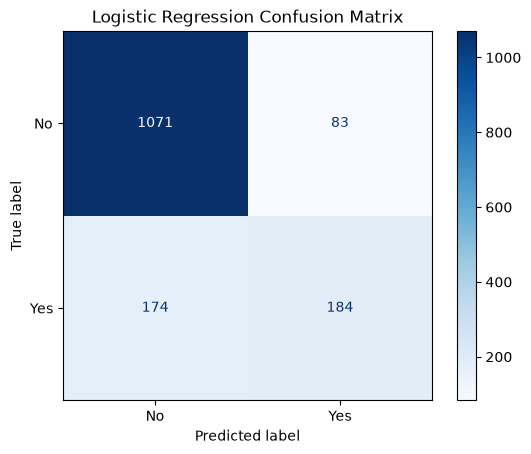

In [52]:
lr_conf_matrix = confusion_matrix(
    y_test,
    lr_pred,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_conf_matrix,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 13. Model Comparison

In [53]:
def model_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Yes)": precision_score(
            y_true, y_pred, pos_label="Yes"
        ),
        "Recall / TPR (Yes)": recall_score(
            y_true, y_pred, pos_label="Yes"
        ),
        "F1 (Yes)": f1_score(
            y_true, y_pred, pos_label="Yes"
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro"
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted"
        ),
    }


comparison = pd.DataFrame(
    {
        "Random Forest": model_metrics(y_test, rf_pred),
        "Logistic Regression": model_metrics(y_test, lr_pred),
    }
).T

display(comparison.style.format("{:.3f}"))

,Accuracy,Precision (Yes),Recall / TPR (Yes),F1 (Yes),Macro F1,Weighted F1
Random Forest,0.845,0.753,0.511,0.609,0.756,0.833
Logistic Regression,0.830,0.689,0.514,0.589,0.741,0.821


### Results from the completed project run

| Metric | Random Forest | Logistic Regression |
| --- | ---: | ---: |
| Accuracy | **85%** | 83% |
| Precision — `Yes` | **75%** | 69% |
| Recall / True Positive Rate — `Yes` | 51% | 51% |
| F1-score — `Yes` | **61%** | 59% |
| Macro F1-score | **76%** | 74% |
| Weighted F1-score | **83%** | 82% |

### Conclusion

The **Random Forest Classifier is better overall predictor** in this experiment.

Logistic Regression achieves a marginally higher positive-class recall (approximately 51% vs. 50%), but Random Forest produces:

- slightly higher overall accuracy,
- substantially higher precision for rainy-day predictions,
- a higher positive-class F1-score,
- and slightly stronger aggregate performance.

The most important limitation is shared by both models: **roughly half of the actual rainy days are still missed**.

## 14. Limitations and Possible Improvements

This project provides a useful classification baseline, but several improvements would be worth exploring:

1. **Missing-data handling**  
   The complete-case approach removes a large amount of data. Model-based or feature-specific imputation could preserve more observations.

2. **Optimization metric**  
   Grid search currently optimizes accuracy. Because `Yes` is the minority class, optimizing positive-class recall, F1-score, or a custom business metric may produce a more useful rainfall detector.

3. **Classification threshold**  
   The default decision threshold may not provide the best precision–recall trade-off. Threshold tuning could improve rainy-day recall.

4. **Additional models**  
   Gradient boosting methods and other ensemble classifiers could be compared with the current models.

5. **Feature engineering**  
   Weather-domain features, lagged measurements, interactions, and cyclic representations of seasonality could be investigated.

6. **Generalization**  
   The model is localized to the Melbourne region. Its performance should not be assumed to generalize to other Australian climates without validation.

7. **Feature importance interpretation**  
   Random Forest impurity-based importance is useful for inspection but should not be interpreted as causal influence.

## Acknowledgements

- Weather observations: **Australian Government Bureau of Meteorology**
- Dataset distribution and educational project framework: **IBM Skills Network**
- Original educational notebook authors: **Jeff Grossman** and contributors listed in the IBM course material

This repository presents my completed implementation, analysis, interpretation, and portfolio-oriented restructuring of the project.